In [15]:
import numpy as np
import matplotlib.pyplot as plt

def condition_initiale(x):
    n = len(x)
    rho0 = np.ones(n) * 1e-20
    u0 = np.ones(n) * 1e-20
    
    mask1 = (x > -2) & (x < -1)
    rho0[mask1] = 2
    u0[mask1] = 1
    
    mask2 = (x > 1) & (x < 5)
    rho0[mask2] = 1
    u0[mask2] = -1
    
    return rho0, u0



In [16]:
def flux(rho, u):
    f1 = u
    f2 = u * u / rho
    return f1, f2

In [17]:

def Flux_Godunov(rhol, rhor, ul, ur, f_rhol, f_rhor, f_rhoul, f_rhour):
    u_chapeau = (np.sqrt(rhol) * ul + np.sqrt(rhor) * ur) / (np.sqrt(rhol) + np.sqrt(rhor))
    
    if ul < 0 and ur > 0:
        f_rho = 0
        f_rhou = 0
    elif u_chapeau > 1e-10:
        f_rho = f_rhol
        f_rhou = f_rhoul
    elif u_chapeau< 0:
        f_rho = f_rhor
        f_rhou = f_rhour
    else:
        f_rho = (f_rhol + f_rhor) / 2
        f_rhou = (f_rhoul + f_rhour) / 2
    
    return f_rho, f_rhou



In [18]:
def solution_exacte(x, t):
    N = len(x)
    rho_exacte = np.zeros(N)
    rhou_exacte = np.zeros(N)
    u_chapeau= (np.sqrt(2) - 1) / (np.sqrt(2) + 1)
    
    if t <= 0:
        mask1 = (x > t - 1) & (x < t)
        rho_exacte[mask1] = 2
        rhou_exacte[mask1] = 2
        
        mask2 = (x > -t) & (x < 4 - t)
        rho_exacte[mask2] = 1
        rhou_exacte[mask2] = -1
        
    elif t > 0 and t <= (np.sqrt(2) + 1) / 2:
        mask1 = (t - 1 <= x) & (x < u_chapeau * t)
        rho_exacte[mask1] = 2
        rhou_exacte[mask1] = 2
        
        mask2 = (x >= u_chapeau * t) & (x < 4 - t)
        rho_exacte[mask2] = 1
        rhou_exacte[mask2] = -1
        
    elif t > (np.sqrt(2) + 1) / 2 and t < 4.25:
        mask1 = (x < -t - 2 + np.sqrt(8 * t + 2)) & (x >= -t - 2 + np.sqrt(8 * t + 2))
        rho_exacte[mask1] = 4 - (2 - np.sqrt(8 * t + 2)) * 5
        rhou_exacte[mask1] = 4 + (2 - np.sqrt(8 * t + 2)) * 5
        
        mask2 = (x > -t - 2 + np.sqrt(8 * t + 2)) & (x < 4 - t)
        rho_exacte[mask2] = 1
        rhou_exacte[mask2] = -1
        
    elif t >= 4.25:
        mask1 = (x < -1/3 * t + 7/6) & (x >= -1/3 * t + 7/6)
        rho_exacte[mask1] = 40
        rhou_exacte[mask1] = -10
        
    return rho_exacte, rhou_exacte



In [19]:
# Initialisation
x = np.linspace(-3, 6, 1000)
rho0, u0 = condition_initiale(x)
rho = rho0.copy()
u = u0.copy()
rhou = rho * u
dx = x[1] - x[0]

# Evolution dans le temps
t = -1
Rho = [rho0]
Rhou = [rho0 * u0]

while t < 6:
    dt = dx / (2 * np.max(np.abs(u)))  # Calcul du pas de temps CFL
    
    # Choix du pas de temps en fonction de t
    if t < -0.5:
        dt = min(dt, -0.5 - t)
    elif -0.5 <= t < 0:
        dt = min(dt, -t)
    elif 0 <= t < 0.5:
        dt = min(dt, 0.5 - t)
    elif 0.5 <= t < 1.5:
        dt = min(dt, 1.5 - t)
    elif 1.5 <= t < 3.5:
        dt = min(dt, 3.5 - t)
    else:
        dt = min(dt, 6 - t)
    
    f_rho, f_rhou = flux(rho, rhou)
    fG_rho = []
    fD_rho = []
    fG_rhou = []
    fD_rhou = []
    
    # Calcul du flux
    for j in range(1, len(rho) - 1):
        fG_rho_j, fG_rhou_j = Flux_Godunov(rho[j-1], rho[j], u[j-1], u[j], f_rho[j-1], f_rho[j], f_rhou[j-1], f_rhou[j])
        fD_rho_j, fD_rhou_j = Flux_Godunov(rho[j], rho[j+1], u[j], u[j+1], f_rho[j], f_rho[j+1], f_rhou[j], f_rhou[j+1])
        fG_rho.append(fG_rho_j)
        fD_rho.append(fD_rho_j)
        fG_rhou.append(fG_rhou_j)
        fD_rhou.append(fD_rhou_j)
    
    # Mise à jour de la solution
    for j in range(1, len(rho) - 1):
        rho[j] = rho[j] - dt / dx * (fD_rho[j-1] - fG_rho[j-1])
        if rho[j] < 1e-20:
            rho[j] = 1e-20
        rhou[j] = rhou[j] - dt / dx * (fD_rhou[j-1] - fG_rhou[j-1])
    
    u = rhou / rho
    t += dt
    
    # Stockage des instants choisis
    if t in [-0.5, 0, 0.5, 1.5, 3.5, 6]:
        Rho.append(rho.copy())
        Rhou.append(rhou.copy())

# Calcul des solutions exactes aux instants choisis
Rho_exacte = []
Rhou_exacte = []

for t in [-0.5, 0, 0.5, 1.5, 3.5, 6]:
    rho_exacte, rhou_exacte = solution_exacte(x, t)
    Rho_exacte.append(rho_exacte)
    Rhou_exacte.append(rhou_exacte)


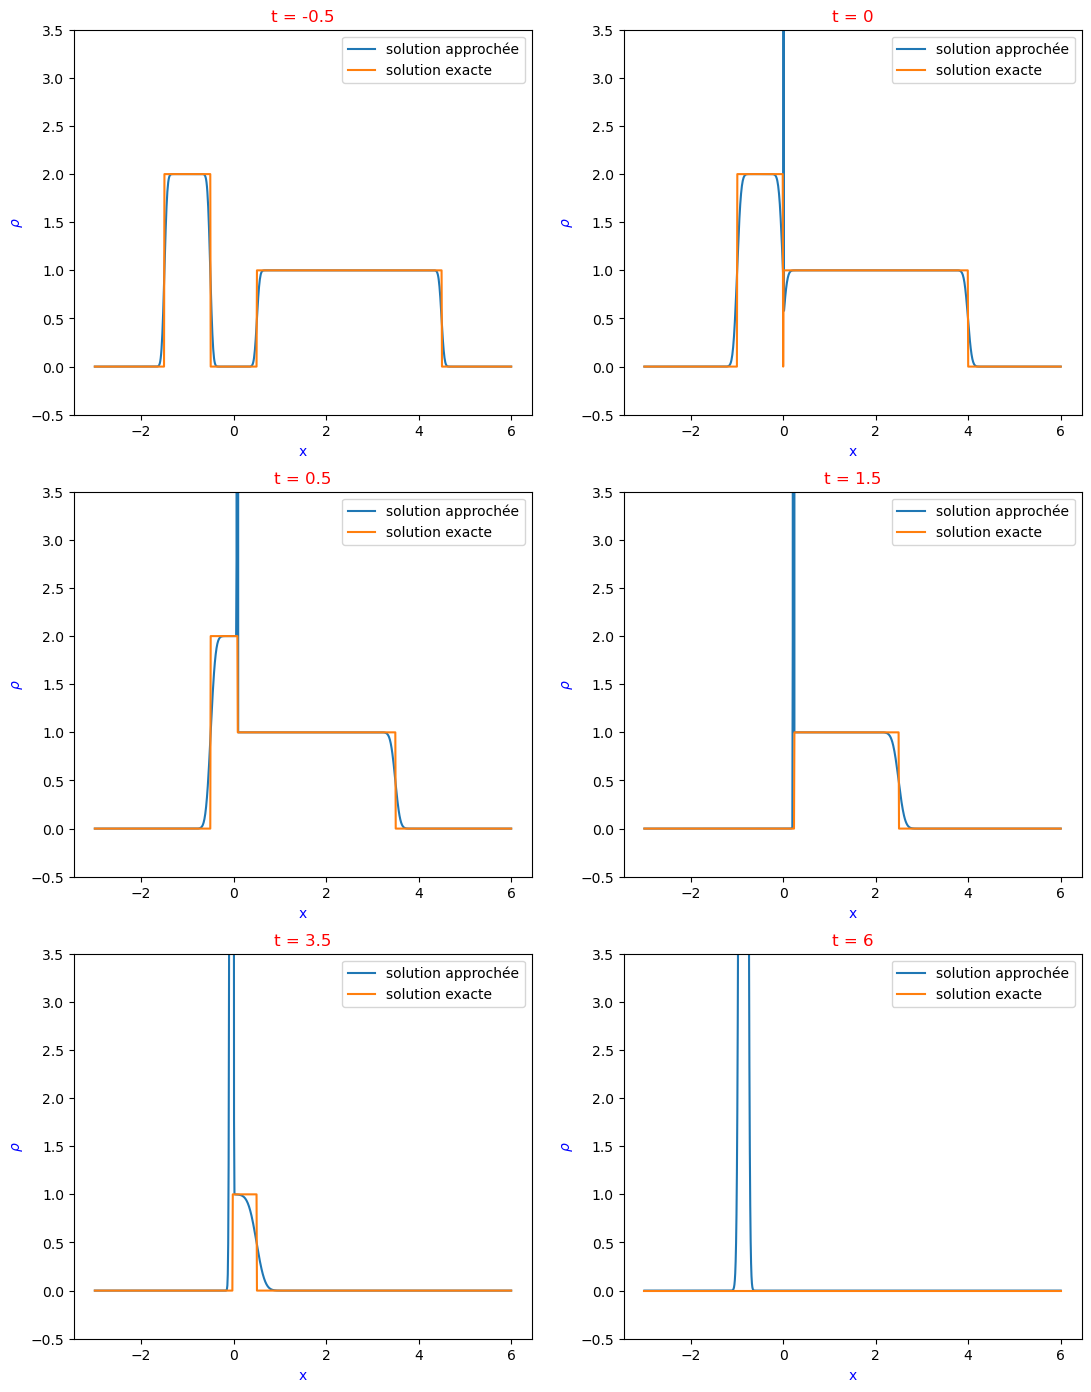

In [20]:

# Affichage des résultats
t_values = [-0.5, 0, 0.5, 1.5, 3.5, 6]
titles = ['t = -0.5', 't = 0', 't = 0.5', 't = 1.5', 't = 3.5', 't = 6']

plt.figure(figsize=(13, 17))

for i in range(len(t_values)):
    plt.subplot(3, 2, i + 1)
    plt.title(titles[i], color='r')
    plt.xlabel('x', color='b')
    plt.ylabel(r'$\rho$', color='b')
    plt.ylim(-0.5, 3.5)
    plt.plot(x, Rho[i+1], label='solution approchée')
    plt.plot(x, Rho_exacte[i], label='solution exacte')
    plt.legend()

plt.show()


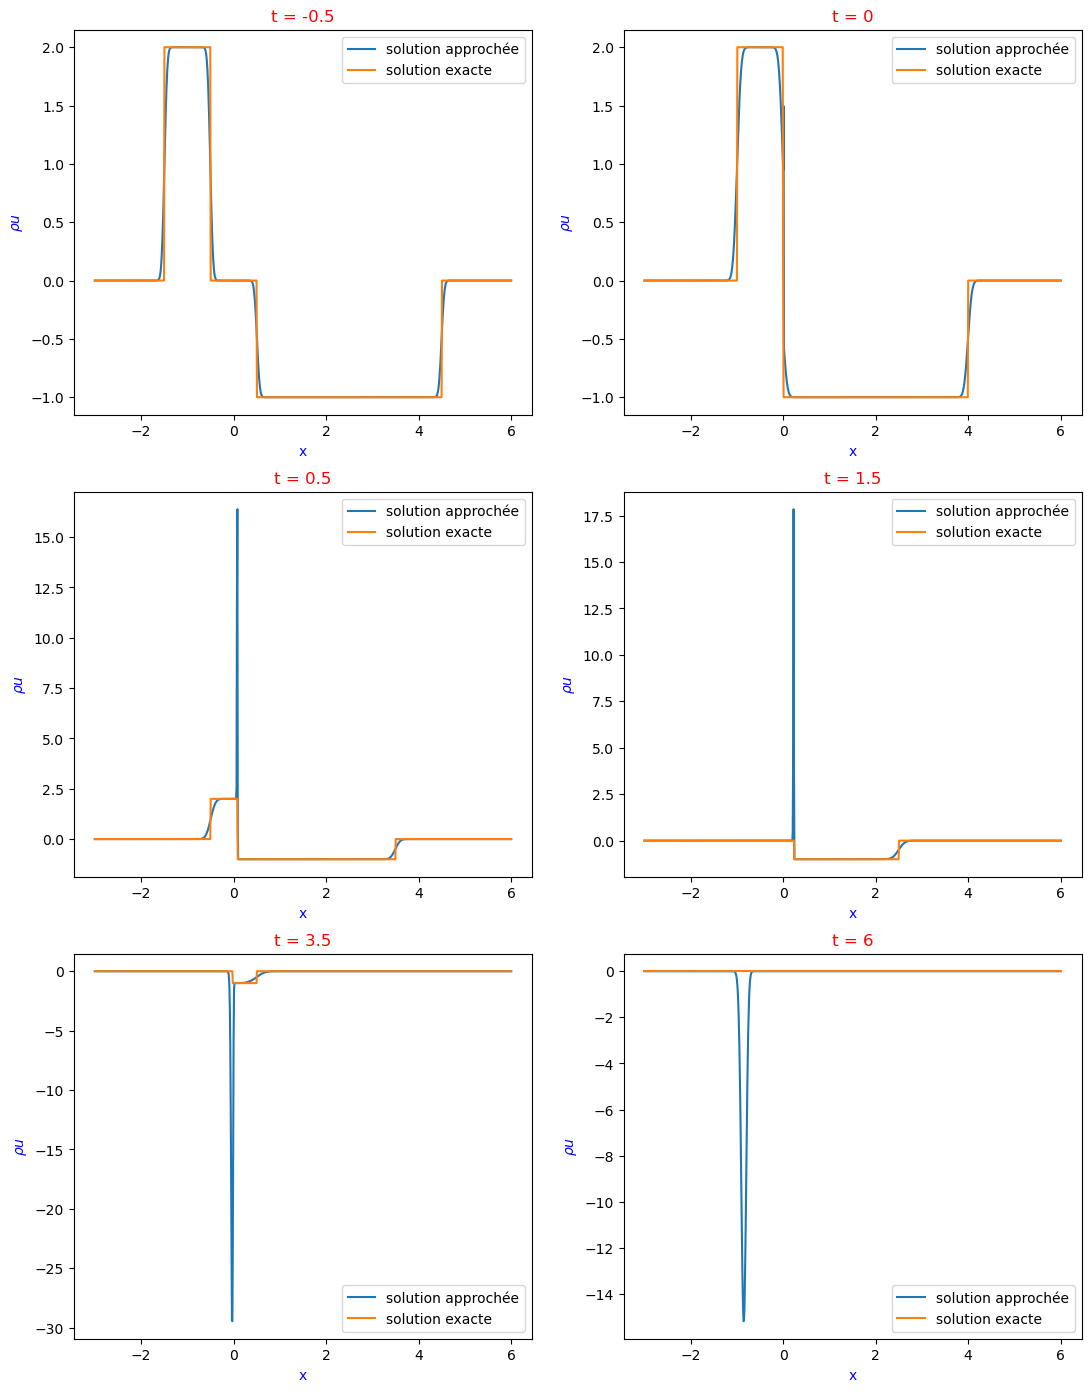

In [21]:

plt.figure(figsize=(13, 17))

for i in range(len(t_values)):
    plt.subplot(3, 2, i + 1)
    plt.title(titles[i], color='r')
    plt.xlabel('x', color='b')
    plt.ylabel(r'$\rho u$', color='b')
    plt.plot(x, Rhou[i+1], label='solution approchée')
    plt.plot(x, Rhou_exacte[i], label='solution exacte')
    plt.legend()

plt.show()
